In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for drawing
import seaborn as sns # for drawing as well
from scipy.optimize import minimize # will use for training
from sklearn.metrics import accuracy_score, f1_score # some metrics
from functools import partial # better google what it is
from tqdm import tqdm as tqdm # nice trackbar
import cv2

import torch # this is the best library for neural networks (IMHO)
import torch.nn as nn # high-level API, useful for deep learning

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
os.listdir('/kaggle/input/digit-recognizer')

['train.csv', 'test.csv', 'sample_submission.csv']

In [2]:
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
target = train['label']

train = train.drop('label', axis=1).values.reshape([-1, 28, 28]) / 255
test = test.values.reshape([-1, 28, 28]) / 255

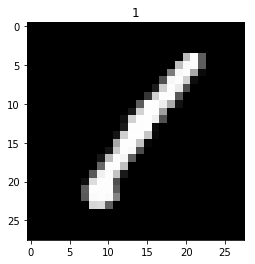

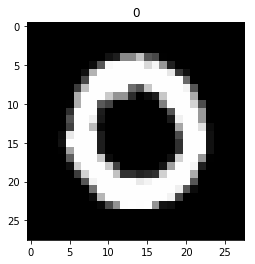

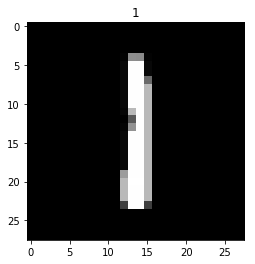

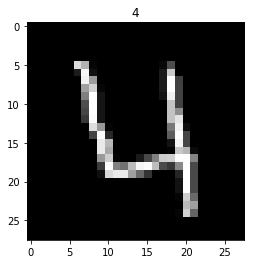

In [4]:
for i in range(4):
    plt.title(target[i])
    plt.imshow(train[i], cmap='gray')
    plt.show()

## EfficientNet
Let's install module

In [5]:
!pip install efficientnet-pytorch

  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.5.1-cp36-none-any.whl size=11768 sha256=7fdae048261529838242ddb8b17500819338cda5b1cb374796508efeb62659c9
  Stored in directory: /tmp/.cache/pip/wheels/52/0c/8e/58d91f29f0f8cbb45231a145312939a5423dc82c61cc731361
Successfully built efficientnet-pytorch


In [6]:
from efficientnet_pytorch import EfficientNet

In [7]:
effnet = EfficientNet.from_pretrained('efficientnet-b0')

Downloading: "http://storage.googleapis.com/public-models/efficientnet/efficientnet-b0-355c32eb.pth" to /tmp/.cache/torch/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 67.5MB/s]

Loaded pretrained weights for efficientnet-b0


In [8]:
img = train[0]
img = cv2.resize(img, (224, 224)) # min 64x64, max inf
img = np.tile(img[None], [3, 1, 1])
img = img[None] # Add batch dimension
img = torch.tensor(img, dtype=torch.float32)
img.shape

torch.Size([1, 3, 224, 224])

In [9]:
feats = effnet.extract_features(img)

In [10]:
feats.shape

torch.Size([1, 1280, 7, 7])

Now let's wrap it into a function

In [11]:
def extract_features(img):
    '''Input: grayscale image'''
    
    # Minimum size required by EfficientNet
    img = cv2.resize(img, (64, 64))
    # Convert grayscale to RGB
    img = np.tile(img[None], [3, 1, 1])
    # Add batch dimension
    img = img[None]
    # Convert to tensor
    img = torch.tensor(img, dtype=torch.float32, device=device)
    
    # Pass image through the neural network
    feats = effnet.extract_features(img)
    
    # Get rid of spatial dimensions
    feats = feats[0].mean(1).mean(1)
    # Convert to numpy
    feats = feats.data.cpu().numpy()
    # float16 takes less memory than float32 (this is optional)
    feats = feats.astype('float16')
    
    return feats

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

effnet = effnet.to(device)

cuda


In [13]:
feats_train = np.array([extract_features(img) for img in tqdm(train)])
feats_test = np.array([extract_features(img) for img in tqdm(test)])

100%|██████████| 28000/28000 [08:27<00:00, 55.22it/s]


In [14]:
print('train', feats_train.shape)
print('test', feats_test.shape)

train (42000, 1280)
test (28000, 1280)


Let's train logistic regression

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(feats_train, target)

predictions = lr.predict(feats_test)

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:469: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


In [16]:
submission = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')
submission.Label = predictions

# Save it as csv file
submission.to_csv('submission_10n.csv', index=False)

submission.head()

,ImageId,Label
0,1,2
1,2,2
2,3,7
3,4,0
4,5,8
